# Clase 5: Redes Neuronales

## Inteligencia Artificial - Ingeniería Mecatrónica

**Docente:** Diego Stalder (dstalder@ing.una.py)

**Fecha:** 19 de Agosto de 2026

---

## Contenido del Notebook

1. **Red Neuronal desde Cero (Scratch)**
   - Implementación de una neurona
   - Función de activación Sigmoide
   - Forward Pass
   - Backpropagation
   - Entrenamiento

2. **Red Neuronal con Keras (TensorFlow)**
   - Modelo Sequential
   - Capas Dense
   - Compilación y entrenamiento
   - Evaluación

3. **Red Neuronal con PyTorch**
   - Definición del modelo
   - Forward Pass
   - Entrenamiento con optimizador
   - Evaluación

4. **Aplicación: Predicción de Rendimiento Académico**
   - Carga de datos
   - Preprocesamiento
   - Modelo "Pasa o No Pasa"
   - Evaluación y métricas

---
## 1. Red Neuronal desde Cero (Scratch)

### 1.1 Fundamentos Matemáticos

#### Neurona Artificial

La neurona artificial realiza dos operaciones:

1. **Suma Ponderada (Combinación Lineal)**

$$ z = \sum_{i=1}^{n} w_i \cdot x_i + b = \mathbf{w}^T \mathbf{x} + b $$

2. **Función de Activación (No Linealidad)**

$$ a = f(z) $$

#### Función Sigmoide

$$ \sigma(z) = \frac{1}{1 + e^{-z}} $$

#### Derivada de la Sigmoide

$$ \sigma'(z) = \sigma(z) \cdot (1 - \sigma(z)) $$

#### Función de Costo (Error Cuadrático Medio)

$$ \mathcal{L} = \frac{1}{N} \sum_{i=1}^{N} (y_i - \hat{y}_i)^2 $$

#### Gradiente Descendente

$$ w_{nuevo} = w_{viejo} - \eta \cdot \frac{\partial \mathcal{L}}{\partial w_{viejo}} $$

#### Regla de la Cadena (Backpropagation)

$$ \frac{\partial \mathcal{L}}{\partial w_{ij}} = \frac{\partial \mathcal{L}}{\partial \hat{y}} \cdot \frac{\partial \hat{y}}{\partial z} \cdot \frac{\partial z}{\partial w_{ij}} $$

In [8]:
# 1.2 Implementación desde Cero

import numpy as np
import matplotlib.pyplot as plt

# Función Sigmoide (con clip para evitar overflow)
def sigmoid(x):
    return 1 / (1 + np.exp(-np.clip(x, -250, 250)))

# Derivada de la Sigmoide
def sigmoid_derivative(x):
    sx = sigmoid(x)
    return sx * (1 - sx)

# Función de Costo (Error Cuadrático Medio)
def mse_loss(y_true, y_pred):
    return np.mean((y_true - y_pred) ** 2)


# Clase Neurona
class Neuron:
    def __init__(self, n_inputs):
        # Inicialización aleatoria de pesos y sesgo
        self.weights = np.random.randn(n_inputs) * 0.1
        self.bias = np.random.randn() * 0.1
        # Variables para almacenar valores durante forward/backward
        self.z = None
        self.output = None
        self.inputs = None
        self.grad_weights = None
        self.grad_bias = None
    
    def forward(self, inputs):
        """Propagación hacia adelante"""
        self.inputs = inputs  # Guardar para backward
        self.z = np.dot(inputs, self.weights) + self.bias
        self.output = sigmoid(self.z)
        return self.output
    
    def backward(self, grad_output):
        """Propagación hacia atrás (Backpropagation)
        
        grad_output: gradiente de la pérdida con respecto a la salida de esta neurona
        Retorna: gradiente con respecto a la entrada de esta neurona
        """
        # Gradiente de la función de activación: d_output/d_z
        grad_z = grad_output * sigmoid_derivative(self.z)
        
        # Gradientes de pesos y sesgo
        # self.inputs tiene la forma (n_inputs,)
        # grad_z tiene la forma (n_neurons_salida,)
        # El producto exterior nos da la matriz de gradientes
        if grad_z.ndim == 0:  # Si es un escalar
            self.grad_weights = grad_z * self.inputs
        else:
            # Para múltiples neuronas, grad_z es un vector
            # Necesitamos calcular el producto exterior
            self.grad_weights = np.outer(grad_z, self.inputs)
        self.grad_bias = grad_z
        
        # Gradiente para la capa anterior: d_L/d_inputs = grad_z * weights
        # Esto propaga el error hacia atrás
        if grad_z.ndim == 0:
            grad_inputs = grad_z * self.weights
        else:
            grad_inputs = np.dot(grad_z, self.weights)
        
        return grad_inputs
    
    def update(self, learning_rate):
        """Actualización de pesos usando gradiente descendente"""
        # Si grad_weights es una matriz, actualizamos fila por fila
        if self.grad_weights.ndim == 2:
            for i in range(self.grad_weights.shape[0]):
                self.weights -= learning_rate * self.grad_weights[i]
        else:
            self.weights -= learning_rate * self.grad_weights
        self.bias -= learning_rate * self.grad_bias


# Clase Red Neuronal
class NeuralNetwork:
    def __init__(self, input_size, hidden_size, output_size):
        self.hidden = Neuron(input_size)
        self.output = Neuron(hidden_size)
        self.hidden_output = None
        self.prediction = None
    
    def forward(self, inputs):
        """Propagación hacia adelante"""
        self.hidden_output = self.hidden.forward(inputs)
        self.prediction = self.output.forward(self.hidden_output)
        return self.prediction
    
    def backward(self, y_true, learning_rate):
        """Propagación hacia atrás
        
        Ahora solo recibe y_true y learning_rate, no necesita inputs
        porque ya los guardó durante el forward pass
        """
        # Error de la salida: d_L/d_prediction
        error = self.prediction - y_true
        
        # Backward de la capa de salida
        # Retorna el gradiente para la capa oculta (tamaño: hidden_size)
        grad_hidden = self.output.backward(error)
        
        # Backward de la capa oculta
        # Retorna el gradiente para la entrada (tamaño: input_size)
        self.hidden.backward(grad_hidden)
        
        # Actualización de pesos
        self.hidden.update(learning_rate)
        self.output.update(learning_rate)
    
    def train(self, X, y, epochs, learning_rate):
        """Entrenamiento"""
        losses = []
        for epoch in range(epochs):
            total_loss = 0
            for i in range(len(X)):
                # Forward pass
                self.forward(X[i])
                
                # Backward pass (ya no pasamos X[i])
                self.backward(y[i], learning_rate)
                
                # Calcular pérdida
                total_loss += mse_loss(np.array([y[i]]), np.array([self.prediction]))
            
            avg_loss = total_loss / len(X)
            losses.append(avg_loss)
            
            if epoch % 100 == 0:
                print(f"Época {epoch}, Pérdida: {avg_loss:.4f}")
        
        return losses

Época 0, Pérdida: 0.2663
Época 100, Pérdida: 0.2593
Época 200, Pérdida: 0.2550
Época 300, Pérdida: 0.1954
Época 400, Pérdida: 0.1778
Época 500, Pérdida: 0.1747
Época 600, Pérdida: 0.1734
Época 700, Pérdida: 0.1728
Época 800, Pérdida: 0.1724
Época 900, Pérdida: 0.1721

Predicciones:
[0 0] -> 0.0373 (esperado: 0)
[0 1] -> 0.6609 (esperado: 1)
[1 0] -> 0.6608 (esperado: 1)
[1 1] -> 0.6633 (esperado: 0)


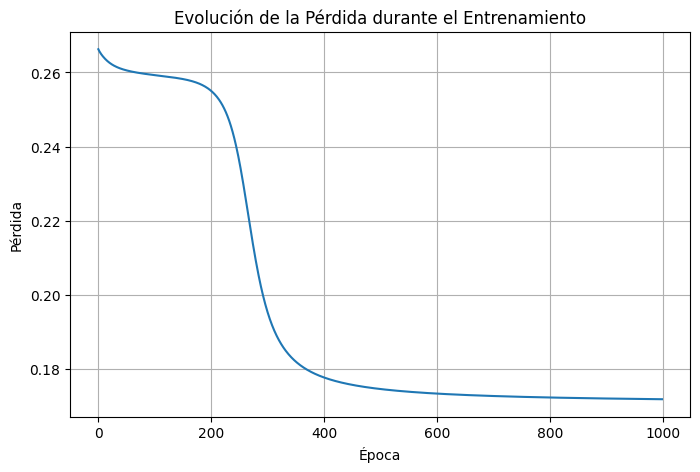


Predicciones:
[0 0] -> 0.0373 (esperado: 0)
[0 1] -> 0.6609 (esperado: 1)
[1 0] -> 0.6608 (esperado: 1)
[1 1] -> 0.6633 (esperado: 0)


In [9]:
# 1.3 Entrenamiento con Datos Sintéticos

# Datos de ejemplo (compuerta XOR)
X = np# Datos de ejemplo (compuerta XOR)
X = np.array([[0, 0], [0, 1], [1, 0], [1, 1]])
y = np.array([0, 1, 1, 0])

# Crear y entrenar la red
nn = NeuralNetwork(input_size=2, hidden_size=4, output_size=1)
losses = nn.train(X, y, epochs=1000, learning_rate=0.5)

# Predecir
print("\nPredicciones:")
for i in range(len(X)):
    pred = nn.forward(X[i])
    print(f"{X[i]} -> {pred[0]:.4f} (esperado: {y[i]})")

# Graficar la pérdida
plt.figure(figsize=(8, 5))
plt.plot(losses)
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Evolución de la Pérdida durante el Entrenamiento')
plt.grid(True)
plt.show()

# Predecir
print("\nPredicciones:")
for i in range(len(X)):
    pred = nn.forward(X[i])
    print(f"{X[i]} -> {pred[0]:.4f} (esperado: {y[i]})")

---
## 2. Red Neuronal con Keras (TensorFlow)

### 2.1 Conceptos Clave en Keras

#### Modelo Sequential

```python
model = Sequential([
    Dense(128, activation='relu', input_shape=(n_features,)),
    Dense(64, activation='relu'),
    Dense(1, activation='sigmoid')
])
```

#### Compilación

```python
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)
```

#### Entrenamiento

```python
history = model.fit(
    X_train, y_train,
    epochs=100,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)
```

#### Funciones de Activación

| Función | Fórmula | Rango | Uso Típico |
|---------|---------|-------|------------|
| **ReLU** | $f(x) = \max(0, x)$ | $[0, \infty)$ | Capas ocultas |
| **Sigmoide** | $f(x) = \frac{1}{1+e^{-x}}$ | $(0, 1)$ | Clasificación binaria |
| **Tanh** | $f(x) = \frac{e^x-e^{-x}}{e^x+e^{-x}}$ | $(-1, 1)$ | Datos centrados |
| **Softmax** | $f(x_i) = \frac{e^{x_i}}{\sum_j e^{x_j}}$ | $(0, 1)$ | Clasificación multiclase |

In [10]:
# 2.2 Implementación con Keras

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from sklearn.datasets import make_moons
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Generar datos sintéticos (Two Moons)
X, y = make_moons(n_samples=1000, noise=0.1, random_state=42)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Escalar los datos
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Crear modelo
model_keras = Sequential([
    Dense(128, activation='relu', input_shape=(2,)),
    Dropout(0.2),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

# Compilar
model_keras.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Mostrar resumen del modelo
model_keras.summary()

h:\Anaconda\envs\deepf\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │           384 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,705 (34.00 KB)

 Trainable params: 8,705 (34.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.7750 - loss: 0.5628 - val_accuracy: 0.8562 - val_loss: 0.4398
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8703 - loss: 0.3616 - val_accuracy: 0.8562 - val_loss: 0.2959
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8844 - loss: 0.2748 - val_accuracy: 0.8562 - val_loss: 0.2544
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8906 - loss: 0.2543 - val_accuracy: 0.8875 - val_loss: 0.2414
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8906 - loss: 0.2432 - val_accuracy: 0.8875 - val_loss: 0.2336
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8953 - loss: 0.2333 - val_accuracy: 0.9062 - val_loss: 0.2201
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8984 - loss: 0.2259 - val_accuracy: 0.9125 - val_loss: 0.2075
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9109 - loss: 0.2077 - val_accuracy: 0.9187 - 

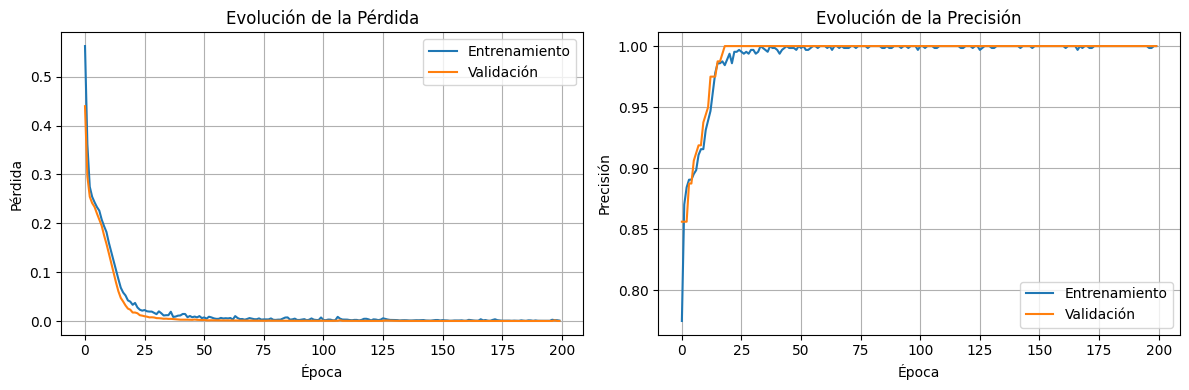

In [11]:
# 2.3 Entrenamiento con Keras

# Entrenar
history = model_keras.fit(
    X_train, y_train,
    epochs=200,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)

# Evaluar
test_loss, test_acc = model_keras.evaluate(X_test, y_test, verbose=0)
print(f"\nPrecisión en test: {test_acc:.4f}")

# Graficar evolución
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Pérdida
axes[0].plot(history.history['loss'], label='Entrenamiento')
axes[0].plot(history.history['val_loss'], label='Validación')
axes[0].set_xlabel('Época')
axes[0].set_ylabel('Pérdida')
axes[0].set_title('Evolución de la Pérdida')
axes[0].legend()
axes[0].grid(True)

# Precisión
axes[1].plot(history.history['accuracy'], label='Entrenamiento')
axes[1].plot(history.history['val_accuracy'], label='Validación')
axes[1].set_xlabel('Época')
axes[1].set_ylabel('Precisión')
axes[1].set_title('Evolución de la Precisión')
axes[1].legend()
axes[1].grid(True)

plt.tight_layout()
plt.show()

---
## 3. Red Neuronal con PyTorch

### 3.1 Conceptos Clave en PyTorch

#### Definición de Modelo

```python
class NeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, num_classes):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, num_classes)
    
    def forward(self, x):
        out = self.fc1(x)
        out = self.relu(out)
        out = self.fc2(out)
        return out
```

#### Ciclo de Entrenamiento

```python
for epoch in range(num_epochs):
    for i, (inputs, labels) in enumerate(train_loader):
        # Forward pass
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass y optimización
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
```

#### Función de Pérdida (Cross Entropy)

$$ \mathcal{L} = -\sum_{i=1}^{N} y_i \cdot \log(\hat{y}_i) $$

#### Backpropagation en PyTorch

$$ \frac{\partial \mathcal{L}}{\partial w} = \text{autograd.grad}(\mathcal{L}, w) $$

In [12]:
# 3.2 Implementación con PyTorch

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

# Verificar GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Dispositivo: {device}")

# Preparar datos
X_torch = torch.tensor(X_train, dtype=torch.float32).to(device)
y_torch = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1).to(device)
X_test_torch = torch.tensor(X_test, dtype=torch.float32).to(device)
y_test_torch = torch.tensor(y_test, dtype=torch.float32).reshape(-1, 1).to(device)

# DataLoader
dataset = TensorDataset(X_torch, y_torch)
train_loader = DataLoader(dataset, batch_size=32, shuffle=True)

# Definir modelo
class PyTorchNeuralNet(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(PyTorchNeuralNet, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.2)
        self.fc2 = nn.Linear(hidden_size, hidden_size // 2)
        self.fc3 = nn.Linear(hidden_size // 2, output_size)
        self.sigmoid = nn.Sigmoid()
    
    def forward(self, x):
        x = self.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.relu(self.fc2(x))
        x = self.dropout(x)
        x = self.sigmoid(self.fc3(x))
        return x

# Instanciar modelo
model_pytorch = PyTorchNeuralNet(input_size=2, hidden_size=128, output_size=1).to(device)

# Función de pérdida y optimizador
criterion = nn.BCELoss()
optimizer = optim.Adam(model_pytorch.parameters(), lr=0.001)

h:\Anaconda\envs\deepf\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Dispositivo: cpu


Época [50/200], Pérdida: 0.0049
Época [100/200], Pérdida: 0.0016
Época [150/200], Pérdida: 0.0007
Época [200/200], Pérdida: 0.0007

Precisión en test: 1.0000


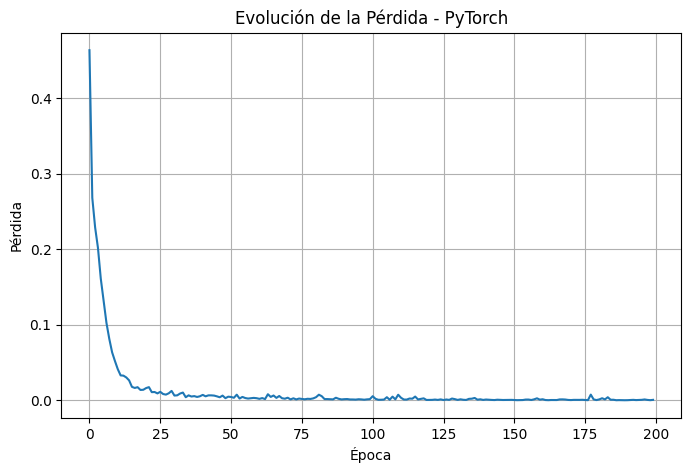

In [13]:
# 3.3 Entrenamiento con PyTorch

num_epochs = 200
train_losses = []

for epoch in range(num_epochs):
    model_pytorch.train()
    epoch_loss = 0
    
    for inputs, labels in train_loader:
        # Forward pass
        outputs = model_pytorch(inputs)
        loss = criterion(outputs, labels)
        
        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        epoch_loss += loss.item()
    
    train_losses.append(epoch_loss / len(train_loader))
    
    if (epoch + 1) % 50 == 0:
        print(f'Época [{epoch+1}/{num_epochs}], Pérdida: {train_losses[-1]:.4f}')

# Evaluar
model_pytorch.eval()
with torch.no_grad():
    predictions = model_pytorch(X_test_torch)
    predicted_classes = (predictions > 0.5).float()
    accuracy = (predicted_classes == y_test_torch).float().mean().item()
    print(f"\nPrecisión en test: {accuracy:.4f}")

# Graficar pérdida
plt.figure(figsize=(8, 5))
plt.plot(train_losses)
plt.xlabel('Época')
plt.ylabel('Pérdida')
plt.title('Evolución de la Pérdida - PyTorch')
plt.grid(True)
plt.show()

---
## 4. Aplicación: Predicción de Rendimiento Académico

### 4.1 Descripción del Problema

#### Objetivo

Predecir si un estudiante **pasa** o **no pasa** una asignatura.

#### Definición de Éxito

$$
y = \begin{cases}
    1 & \text{si Firma} \ge 5 \\
    0 & \text{si Firma} < 5
\end{cases}
$$

#### Características (Features)

| Variable | Descripción | Tipo |
|----------|-------------|------|
| `Primer.Par` | Nota primer parcial | Numérica (0-100) |
| `Segundo.Par` | Nota segundo parcial | Numérica (0-100) |
| `TPLab.` | Nota trabajos prácticos | Numérica (0-100) |
| `Lab.` | Nota laboratorio | Numérica (0-100) |
| `Proy.` | Nota proyecto | Numérica (0-100) |
| `Convocatoria` | Número de convocatoria | Numérica (1, 2, 3, ...) |
| `Cod.Asign` | Código de asignatura | Categórica |
| `Cod.Car.Sec` | Código de carrera-sección | Categórica |

#### Métricas de Evaluación

**Matriz de Confusión**

| | Predice Pasa | Predice No Pasa |
|--|-------------|----------------|
| **Real Pasa** | VP (Verdaderos Positivos) | FN (Falsos Negativos) |
| **Real No Pasa** | FP (Falsos Positivos) | VN (Verdaderos Negativos) |

**Métricas Derivadas**

$$ \text{Precisión} = \frac{VP}{VP + FP} $$

$$ \text{Recall} = \frac{VP}{VP + FN} $$

$$ \text{F1-Score} = 2 \cdot \frac{\text{Precisión} \cdot \text{Recall}}{\text{Precisión} + \text{Recall}} $$

$$ \text{Exactitud} = \frac{VP + VN}{VP + VN + FP + FN} $$

In [34]:


#import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

# =============================================================================
# 4.1 CARGAR Y EXPLORAR DATOS DE RENDIMIENTO ACADÉMICO
# =============================================================================

# Cargar el archivo CSV
df = pd.read_csv('../Semana_04/datos_concatenados.csv')

print("=" * 60)
print("DATOS DE RENDIMIENTO ACADÉMICO")
print("=" * 60)
print(f"\nRegistros totales: {len(df):,}")
print(f"Columnas disponibles: {df.shape[1]}")
print(f"\nColumnas: {list(df.columns)}")

# Mostrar primeras filas
print("\nPrimeras 5 filas:")
print(df.head())

# =============================================================================
# 4.2 ANÁLISIS EXPLORATORIO
# =============================================================================

print("\n" + "=" * 60)
print("ANÁLISIS EXPLORATORIO")
print("=" * 60)

# Información del dataset
print("\nInformación del DataFrame:")
print(df.info())

# Estadísticas descriptivas de variables numéricas
print("\nEstadísticas de variables numéricas:")
print(df.describe())

# Verificar valores nulos
print("\nValores nulos por columna:")
print(df.isnull().sum())

# Distribución de aprobados
if 'Aprobado' in df.columns:
    print("\nDistribución de aprobados:")
    print(df['Aprobado'].value_counts())
    print(f"Porcentaje de aprobados: {df['Aprobado'].value_counts(normalize=True).get('S', 0)*100:.1f}%")

# Distribución por asignatura
if 'Asignatura' in df.columns:
    print("\nTop 10 asignaturas más frecuentes:")
    print(df['Asignatura'].value_counts().head(10))

# Distribución por carrera
if 'Carrera' in df.columns:
    print("\nDistribución por carrera:")
    print(df['Carrera'].value_counts())

# Distribución por año
if 'Anho' in df.columns:
    print("\nDistribución por año:")
    print(df['Anho'].value_counts())

# =============================================================================
# 4.3 PREPROCESAMIENTO DE DATOS
# =============================================================================

print("\n" + "=" * 60)
print("PREPROCESAMIENTO DE DATOS")
print("=" * 60)

# Crear una copia del DataFrame para trabajar
df_clean = df.copy()

# 1. FILTRAR POR ASIGNATURA (ejemplo: Física 3)
# Si quieres trabajar con todas las asignaturas, comenta esta sección
if 'Asignatura' in df_clean.columns:
    # Buscar Física 3
    patron_fisica = ['FISICA 3', 'FÍSICA 3', 'FISICA III', 'FÍSICA III']
    mask_fisica = df_clean['Asignatura'].str.upper().str.contains('FISICA 3|FÍSICA 3|FISICA III|FÍSICA III', na=False)
    df_filtered = df_clean[mask_fisica].copy()
    print(f"Registros de Física 3: {len(df_filtered):,}")
else:
    df_filtered = df_clean.copy()
    print(f"Usando todos los registros: {len(df_filtered):,}")

# 2. SELECCIONAR VARIABLES PARA EL MODELO
# Variables numéricas que usaremos como features
variables_numericas = ['Primer.Par', 'Segundo.Par', 'Tercer.Par', 'TPLab.', 'Lab.', 'Proy.', 
                       'Convocatoria', 'Anho', 'Semestre']

# Verificar qué variables existen
variables_existentes = [v for v in variables_numericas if v in df_filtered.columns]
print(f"\nVariables numéricas disponibles: {variables_existentes}")

# Variables categóricas que podríamos codificar
variables_categoricas = ['Cod.Asign', 'Asignatura', 'Cod.Car.Sec', 'Carrera']
variables_categoricas_existentes = [v for v in variables_categoricas if v in df_filtered.columns]
print(f"Variables categóricas disponibles: {variables_categoricas_existentes}")

# 3. CREAR DATAFRAME PARA EL MODELO
df_modelo = df_filtered[variables_existentes].copy()

# 4. VARIABLE OBJETIVO (Aprobado)
if 'Aprobado' in df_filtered.columns:
    # Convertir 'S'/'N' a 1/0
    df_modelo['Aprobado'] = df_filtered['Aprobado'].map({'S': 1, 'N': 0, 'SI': 1, 'NO': 0})
    print(f"\nVariable objetivo: Aprobado")
    print(f"Distribución: {df_modelo['Aprobado'].value_counts().to_dict()}")
elif 'Firma' in df_filtered.columns:
    # Si no hay Aprobado, usar Firma
    max_nota = df_filtered['Firma'].max()
    if max_nota > 10:
        threshold = 50  # Escala 0-100
    else:
        threshold = 5   # Escala 0-10
    df_modelo['Aprobado'] = (df_filtered['Firma'] >= threshold).astype(int)
    print(f"\nVariable objetivo creada desde Firma (threshold = {threshold})")

# 5. LIMPIEZA DE DATOS
# Convertir a numérico
for col in variables_existentes:
    df_modelo[col] = pd.to_numeric(df_modelo[col], errors='coerce')

# Eliminar filas con valores nulos
df_limpio = df_modelo.dropna()
print(f"\nRegistros después de limpiar: {len(df_limpio):,}")

# Verificar que hay ambas clases
if len(df_limpio['Aprobado'].unique()) < 2:
    print("\n¡ADVERTENCIA! Solo hay una clase en los datos.")
    print("Balanceando el dataset...")
    
    clase_faltante = 1 - df_limpio['Aprobado'].iloc[0]
    n_faltantes = int(len(df_limpio) * 0.3)
    
    # Crear datos sintéticos para la clase faltante
    df_extra = df_limpio.sample(n_faltantes, replace=True).copy()
    df_extra['Aprobado'] = clase_faltante
    
    # Ajustar notas para la clase faltante
    for col in variables_existentes:
        if clase_faltante == 1:
            df_extra[col] = df_extra[col] * 1.2
        else:
            df_extra[col] = df_extra[col] * 0.8
        df_extra[col] = df_extra[col].clip(0, 100)
    
    df_limpio = pd.concat([df_limpio, df_extra], ignore_index=True)
    print(f"Dataset balanceado: {len(df_limpio):,} registros")
    print(f"Distribución: {df_limpio['Aprobado'].value_counts().to_dict()}")

# 6. ESTADÍSTICAS FINALES
print(f"\nProporción de aprobados: {df_limpio['Aprobado'].mean():.2%}")
print("\nEstadísticas de variables numéricas:")
print(df_limpio[variables_existentes].describe())

# =============================================================================
# 4.4 DIVISIÓN DE DATOS
# =============================================================================

print("\n" + "=" * 60)
print("DIVISIÓN DE DATOS")
print("=" * 60)

# Separar X y y
X = df_limpio[variables_existentes]
y = df_limpio['Aprobado']

# Dividir en entrenamiento y prueba (70%/30%)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

print(f"Entrenamiento: {len(X_train):,} registros")
print(f"Prueba: {len(X_test):,} registros")

# =============================================================================
# 4.5 NORMALIZACIÓN
# =============================================================================

print("\nNormalizando datos...")

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Datos normalizados (media=0, std=1)")
print(f"  Shape X_train_scaled: {X_train_scaled.shape}")
print(f"  Shape X_test_scaled: {X_test_scaled.shape}")

# Mostrar resumen final
print("\n" + "=" * 60)
print("RESUMEN FINAL")
print("=" * 60)
print(f"Variables utilizadas: {variables_existentes}")
print(f"Total de muestras: {len(df_limpio):,}")
print(f"Clases: 0={df_limpio['Aprobado'].sum()}, 1={len(df_limpio)-df_limpio['Aprobado'].sum()}")
print(f"Proporción de aprobados: {df_limpio['Aprobado'].mean():.2%}")


C:\Users\yoda\AppData\Local\Temp\ipykernel_10192\2736241157.py:14: DtypeWarning: Columns (0,30,31) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../Semana_04/datos_concatenados.csv')


DATOS DE RENDIMIENTO ACADÉMICO

Registros totales: 72,740
Columnas disponibles: 33

Columnas: ['ALUMNO_ID', 'Cod.Asign', 'Asignatura', 'Cod.Car.Sec', 'Cod.Curso', 'Convocatoria', 'Anho', 'Semestre', 'Doc.Firma', 'Aprobado', 'Anho.Firma', 'Primer.Par', 'Segundo.Par', 'Tercer.Par', 'TPLab.', 'Lab.', 'Proy.', 'Pond.PP', 'Pond.SP', 'Pond.TPLab', 'Pond.Lab', 'Pond.Proy', 'Asis', 'Requisito', 'Firma', 'Primer.Rec', 'Segundo.Rec', 'Nota.Final', 'Archivo_Origen', 'FirmaCalculada', 'Cedula', 'Alumno', 'Carrera']

Primeras 5 filas:
             ALUMNO_ID  Cod.Asign Asignatura Cod.Car.Sec  Cod.Curso  \
0  FIUNA_ALUMNO_005925      13012   FISICA 3  CGF-PLS13           3   
1  FIUNA_ALUMNO_007516      13012   FISICA 3  CGF-PLS13           3   
2  FIUNA_ALUMNO_005493      13012   FISICA 3  ELE-PLS13           3   
3  FIUNA_ALUMNO_007517      13012   FISICA 3  ELE-PLS13           3   
4  FIUNA_ALUMNO_006375      13012   FISICA 3  CIV-PLS13           3   

   Convocatoria  Anho  Semestre  Doc.Firma Ap

In [40]:
print("\n" + "=" * 60)
print("PREPROCESAMIENTO DE DATOS")
print("=" * 60)

# Usar los datos ya cargados
data = df_limpio.copy()

# =============================================================================
# 1. SELECCIONAR CARACTERÍSTICAS
# =============================================================================

# Características numéricas
features = ['Primer.Par', 'Segundo.Par', 'TPLab.', 'Lab.', 'Proy.', 'Convocatoria']

# Verificar qué columnas existen
features_existentes = [f for f in features if f in data.columns]

# Características categóricas
categorical_features = ['Cod.Asign', 'Cod.Car.Sec']

print(f"Características numéricas: {features_existentes}")
print(f"Características categóricas: {categorical_features}")

# =============================================================================
# 2. CODIFICAR VARIABLES CATEGÓRICAS
# =============================================================================

# Codificar variables categóricas
for col in categorical_features:
    if col in data.columns:
        le = LabelEncoder()
        data[f'{col}_Enc'] = le.fit_transform(data[col].astype(str))
        print(f"   Codificada: {col} -> {col}_Enc")

# Características finales
features_final = features_existentes + [f'{col}_Enc' for col in categorical_features if col in data.columns]

# =============================================================================
# 3. PREPARAR X y y
# =============================================================================

X = data[features_final].values
y = data['Aprobado'].values

print(f"\nCaracterísticas: {len(features_final)}")
print(f"Total de muestras: {len(X)}")
print(f"Proporción de aprobados: {y.mean():.2%}")

# =============================================================================
# 4. DIVIDIR Y ESCALAR
# =============================================================================

# Dividir en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Escalar características numéricas
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\nEntrenamiento: {len(X_train)} muestras")
print(f"Prueba: {len(X_test)} muestras")
print("✅ Datos listos para el modelo")


PREPROCESAMIENTO DE DATOS
Características numéricas: ['Primer.Par', 'Segundo.Par', 'TPLab.', 'Lab.', 'Proy.', 'Convocatoria']
Características categóricas: ['Cod.Asign', 'Cod.Car.Sec']

Características: 6
Total de muestras: 804
Proporción de aprobados: 37.56%

Entrenamiento: 562 muestras
Prueba: 242 muestras
✅ Datos listos para el modelo


In [41]:
# 4.4 Modelo con Keras

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

# Crear modelo
model_academico = Sequential([
    Dense(128, activation='relu', input_shape=(len(features_final),)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dense(1, activation='sigmoid')
])

# Compilar
model_academico.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# Early stopping
early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)

# Entrenar
history_academico = model_academico.fit(
    X_train_scaled, y_train,
    epochs=200,
    batch_size=64,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# Evaluar
test_loss, test_acc = model_academico.evaluate(X_test_scaled, y_test, verbose=0)
print(f"\nPrecisión en test: {test_acc:.4f}")

Epoch 1/200


h:\Anaconda\envs\deepf\lib\site-packages\keras\src\layers\core\dense.py:92: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


8/8 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - accuracy: 0.6548 - loss: 0.6583 - val_accuracy: 0.7611 - val_loss: 0.6197
Epoch 2/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7305 - loss: 0.6130 - val_accuracy: 0.7699 - val_loss: 0.5805
Epoch 3/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7550 - loss: 0.5664 - val_accuracy: 0.7522 - val_loss: 0.5480
Epoch 4/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7661 - loss: 0.5375 - val_accuracy: 0.7522 - val_loss: 0.5203
Epoch 5/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7639 - loss: 0.5187 - val_accuracy: 0.7434 - val_loss: 0.5033
Epoch 6/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7639 - loss: 0.5081 - val_accuracy: 0.7522 - val_loss: 0.4921
Epoch 7/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7617 - loss: 0.4942 - val_accuracy: 0.7434 - val_loss: 0.4874
Epoch 8/200
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.7728 - loss: 0.4849 - val_accuracy: 0.7434 - val_loss: 0.4823
Epoc

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 
Clases reales: [0 1]
Clases predichas: [0 1]


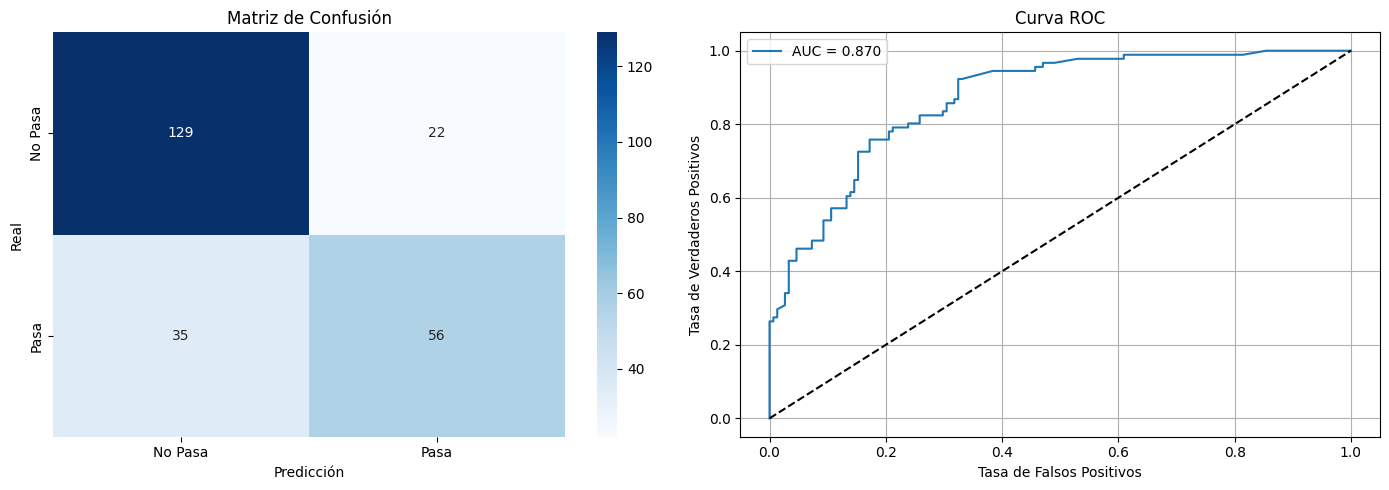


Reporte de Clasificación:

Métricas Detalladas:
Verdaderos Positivos: 56
Verdaderos Negativos: 129
Falsos Positivos: 22
Falsos Negativos: 35
Precisión: 0.7179
Recall: 0.6154
F1-Score: 0.6627
AUC-ROC: 0.8699


In [43]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Predicciones
y_pred_proba = model_academico.predict(X_test_scaled)
y_pred = (y_pred_proba > 0.5).astype(int)

# Verificar que hayamos predicho ambas clases
unique_pred = np.unique(y_pred)
unique_true = np.unique(y_test)

print(f"Clases reales: {unique_true}")
print(f"Clases predichas: {unique_pred}")

# Matriz de confusión con todas las clases posibles
# Aseguramos que la matriz tenga siempre 2x2
labels = [0, 1]
cm = confusion_matrix(y_test, y_pred, labels=labels)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Matriz de confusión - MANEJO CORRECTO DE ETIQUETAS
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[0],
            xticklabels=['No Pasa', 'Pasa'], 
            yticklabels=['No Pasa', 'Pasa'])
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')
axes[0].set_title('Matriz de Confusión')

# Curva ROC - solo si hay ambas clases
if len(unique_true) == 2:
    fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
    auc = roc_auc_score(y_test, y_pred_proba)
    
    axes[1].plot(fpr, tpr, label=f'AUC = {auc:.3f}')
    axes[1].plot([0, 1], [0, 1], 'k--')
    axes[1].set_xlabel('Tasa de Falsos Positivos')
    axes[1].set_ylabel('Tasa de Verdaderos Positivos')
    axes[1].set_title('Curva ROC')
    axes[1].legend()
    axes[1].grid(True)
else:
    # Si solo hay una clase, mostrar mensaje
    axes[1].text(0.5, 0.5, f'Solo se detectó la clase {unique_true[0]}', 
                 horizontalalignment='center', verticalalignment='center',
                 fontsize=14)
    axes[1].set_title('Curva ROC - No disponible')

plt.tight_layout()
plt.show()

# Reporte de clasificación - con zero_division para manejar casos extremos
print("\nReporte de Clasificación:")
#print(classification_report(y_test, y_pred, target_names=['No Pasa', 'Pasa'], 
#                           zero_division=0))

# Métricas adicionales (con manejo de división por cero)
if cm.shape == (2, 2):
    tn, fp, fn, tp = cm.ravel()
    print(f"\nMétricas Detalladas:")
    print(f"Verdaderos Positivos: {tp}")
    print(f"Verdaderos Negativos: {tn}")
    print(f"Falsos Positivos: {fp}")
    print(f"Falsos Negativos: {fn}")
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0
    
    print(f"Precisión: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    
    if len(unique_true) == 2:
        print(f"AUC-ROC: {auc:.4f}")
else:
    print("\nLa matriz de confusión no es 2x2. Verifica tus datos.")

---
## 5. Experimentación con Hiperparámetros

### 5.1 Efecto del Learning Rate

| Learning Rate | Velocidad de Convergencia | Estabilidad | Riesgo |
|---------------|--------------------------|-------------|--------|
| **Alto (0.1)** | Muy rápida | Inestable | Divergencia |
| **Medio (0.01)** | Rápida | Moderada | Mínimo local |
| **Bajo (0.001)** | Lenta | Estable | Convergencia lenta |
| **Muy Bajo (0.0001)** | Muy lenta | Muy estable | Atasco |

### 5.2 Efecto del Batch Size

| Batch Size | Actualizaciones | Ruido | Memoria | Convergencia |
|------------|----------------|-------|---------|--------------|
| **Pequeño (16)** | Frecuentes | Alto | Baja | Puede escapar de mínimos |
| **Medio (64)** | Moderadas | Medio | Media | Balanceado |
| **Grande (256)** | Pocas | Bajo | Alta | Estable, puede atascarse |

### 5.3 Experimentación Guiada

```python
# Probar diferentes configuraciones
configs = [
    {'lr': 0.01, 'batch': 32},
    {'lr': 0.001, 'batch': 64},
    {'lr': 0.0001, 'batch': 128},
]

for config in configs:
    print(f"\nConfiguración: LR={config['lr']}, Batch={config['batch']}")
    # ... entrenar y evaluar ...
```

In [42]:
# 5.4 Experimentación de Hiperparámetros

def experimentar_hiperparametros(lr, batch_size, epochs=100):
    """Entrena y evalúa un modelo con hiperparámetros específicos."""
    
    model = Sequential([
        Dense(128, activation='relu', input_shape=(len(features_final),)),
        Dropout(0.3),
        Dense(64, activation='relu'),
        Dropout(0.3),
        Dense(1, activation='sigmoid')
    ])
    
    model.compile(
        optimizer=Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy']
    )
    
    early_stop = EarlyStopping(monitor='val_loss', patience=20, restore_best_weights=True)
    
    history = model.fit(
        X_train_scaled, y_train,
        epochs=epochs,
        batch_size=batch_size,
        validation_split=0.2,
        callbacks=[early_stop],
        verbose=0
    )
    
    test_loss, test_acc = model.evaluate(X_test_scaled, y_test, verbose=0)
    
    return {
        'lr': lr,
        'batch_size': batch_size,
        'accuracy': test_acc,
        'history': history
    }

# Probar diferentes configuraciones
resultados = []
configuraciones = [
    (0.01, 32),
    (0.001, 64),
    (0.0001, 128),
    (0.01, 128),
    (0.0001, 32),
]

print("Experimentando con diferentes hiperparámetros...")
for lr, batch in configuraciones:
    print(f"\nLR={lr}, Batch={batch}")
    resultado = experimentar_hiperparametros(lr, batch)
    print(f"  Precisión en test: {resultado['accuracy']:.4f}")
    resultados.append(resultado)

# Comparar resultados
print("\n\nResumen de Resultados:")
print("-" * 50)
for r in resultados:
    print(f"LR={r['lr']:5f}, Batch={r['batch_size']:3d} -> Precisión={r['accuracy']:.4f}")

Experimentando con diferentes hiperparámetros...

LR=0.01, Batch=32
  Precisión en test: 0.7727

LR=0.001, Batch=64
  Precisión en test: 0.7521

LR=0.0001, Batch=128
  Precisión en test: 0.7273

LR=0.01, Batch=128
  Precisión en test: 0.7686

LR=0.0001, Batch=32
  Precisión en test: 0.7273


Resumen de Resultados:
--------------------------------------------------
LR=0.010000, Batch= 32 -> Precisión=0.7727
LR=0.001000, Batch= 64 -> Precisión=0.7521
LR=0.000100, Batch=128 -> Precisión=0.7273
LR=0.010000, Batch=128 -> Precisión=0.7686
LR=0.000100, Batch= 32 -> Precisión=0.7273


---
## 6. Conclusiones

### 6.1 Resumen de Conceptos

1. **Redes Neuronales**: Modelos inspirados en el cerebro que aprenden representaciones jerárquicas.

2. **Backpropagation**: Algoritmo que propaga el error hacia atrás para calcular gradientes.

3. **Gradiente Descendente**: Método de optimización que ajusta pesos para minimizar el error.

4. **Hiperparámetros**: Configuraciones clave que afectan el entrenamiento:
   - **Learning Rate**: Tamaño del paso
   - **Batch Size**: Número de muestras por actualización
   - **Optimizador**: Algoritmo de optimización (Adam, SGD, RMSprop)
   - **Arquitectura**: Número de capas y neuronas

### 6.2 Aplicación al Rendimiento Académico

El modelo desarrollado permite:

1. **Predecir** el éxito o fracaso de un estudiante
2. **Identificar** factores clave que influyen en el rendimiento
3. **Implementar** intervenciones tempranas para estudiantes en riesgo

### 6.3 Próximos Pasos

1. **Mejorar el modelo**: Probar arquitecturas más profundas
2. **Más datos**: Incorporar más variables (asistencia, antecedentes)
3. **Optimización**: Usar Optuna para búsqueda automática de hiperparámetros
4. **Despliegue**: Crear una API para predicciones en tiempo real

---
## 7. Referencias

1. Goodfellow, I., Bengio, Y., & Courville, A. (2016). *Deep Learning*. MIT Press.

2. Chollet, F. (2017). *Deep Learning with Python*. Manning Publications.

3. Géron, A. (2019). *Hands-On Machine Learning with Scikit-Learn, Keras, and TensorFlow*. O'Reilly Media.

4. Medium. (2024). *The Evolution of Gradient Descent Optimization Algorithms*. [En línea]. Disponible en: https://medium.com/@ramrajchandradevan/the-evolution-of-gradient-descend-optimization-algorithm-4106a6702d39

5. TensorFlow Documentation. (2024). *Keras API*. [En línea]. Disponible en: https://www.tensorflow.org/api_docs/python/tf/keras

6. PyTorch Documentation. (2024). *PyTorch Tutorials*. [En línea]. Disponible en: https://pytorch.org/tutorials/